# Feature Evaluation — ETFs

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Evaluate individual feature predictive power via Information Coefficient (IC)
- Apply HAC adjustment for overlapping-return autocorrelation
- Control false discovery rate with Benjamini-Hochberg correction
- Assess feature redundancy and family-level signal concentration
- Produce a triage ledger for downstream model selection

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation)

**Prerequisites**: `03_financial_features.py` and `04_temporal.py` must have run
(produces `features/financial.parquet` and `features/model_based.parquet`).

In [1]:
"""Feature Evaluation - ETFs case study."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from utils.paths import get_case_study_dir

In [2]:
# Production defaults
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "etfs"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

# ETFs config
PRIMARY_LABEL_FILE = "fwd_ret_21d.parquet"
HAC_MAXLAGS = 21  # 21-day forward return
MIN_PERIODS = 10  # 99 symbols
IC_THRESHOLD = 0.01  # Monthly horizon

## 0. Load Artifacts & Build Evaluation Panel

We load the pre-computed feature matrices and labels, then join into a single
evaluation panel. Temporal features include both date-level (HMM regime, FFD)
and per-symbol (GARCH) features, so we join on `[date, symbol]`.

In [4]:
# Load features (normalize date column type to pl.Date for consistent joins)
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet").with_columns(
    pl.col("timestamp").cast(pl.Date)
)
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet").with_columns(
    pl.col("timestamp").cast(pl.Date)
)
# model_based.parquet now carries one row per (timestamp, symbol, fold);
# drop fold and de-dup so the join doesn't multiply the eval panel by fold count.
if "fold" in temporal.columns:
    temporal = temporal.drop("fold").unique(subset=["timestamp", "symbol"], keep="last")

# Load primary label
label_df = pl.read_parquet(CASE_DIR / "labels" / PRIMARY_LABEL_FILE).with_columns(
    pl.col("timestamp").cast(pl.Date)
)
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol")][0]

# Load evaluation config from setup.yaml
with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup_config = yaml.safe_load(f)
eval_config = setup_config.get("evaluation", {})

print(f"Features: {features.shape}")
print(f"Temporal: {temporal.shape}")
print(f"Labels: {label_df.shape}, column: {label_col}")

Features: (396186, 59)
Temporal: (470662, 16)
Labels: (468562, 3), column: fwd_ret_21d


In [5]:
# Identify feature columns by source
JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

financial_cols = [c for c in features.columns if c not in JOIN_COLS]
temporal_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol")]

# Join: features + temporal (on [date, symbol]) + labels
eval_panel = features.join(temporal, on=JOIN_COLS, how="left")
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

all_feature_cols = financial_cols + temporal_cols

if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"\nEval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} dates")
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")


Eval panel: 394,233 rows, 99 symbols, 4,759 dates
Features: 57 financial + 14 temporal = 71 total
Label: fwd_ret_21d


## 0.5 Data Quality Gate

Verify upstream artifacts are free of critical defects (negative prices,
infinities, extreme returns) before any statistical evaluation.

In [6]:
from utils.data_quality import validate_modeling_inputs

validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=1.0,  # 21-day ETF returns (max observed ~0.71)
    fail_on_critical=True,
)

Data Quality Gate: 0 CRITICAL, 1 WARNING
  [!] WARNING: 2 features have values |x| > 1e+06: sharpe_5d(172), sharpe_10d(37)


{'issues': ['WARNING: 2 features have values |x| > 1e+06: sharpe_5d(172), sharpe_10d(37)'],
 'n_critical': 0,
 'n_warning': 1}

## 1. Correctness Screens

Before evaluating predictive power, we check data quality:
- **Coverage**: fraction of non-null values (threshold: 70%)
- **Staleness**: fraction of unchanged values from prior date (threshold: 50%)

Features that fail either gate are marked STOP in the triage.

In [7]:
coverage = {}
staleness = {}

for feat in all_feature_cols:
    col = eval_panel[feat]
    coverage[feat] = col.drop_nulls().len() / n_rows

    # Staleness: fraction unchanged from prior row within same symbol
    unchanged = (
        eval_panel.sort(JOIN_COLS)
        .select((pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("same"))["same"]
        .sum()
    )
    staleness[feat] = float(unchanged) / max(n_rows - n_symbols, 1)

correctness = {
    feat: coverage[feat] >= 0.70 and staleness[feat] <= 0.50 for feat in all_feature_cols
}
n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [round(coverage[f], 3) for f, ok in correctness.items() if not ok],
            "staleness": [round(staleness[f], 3) for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 67 PASS, 4 FAIL
shape: (4, 3)
┌──────────────────┬──────────┬───────────┐
│ feature          ┆ coverage ┆ staleness │
│ ---              ┆ ---      ┆ ---       │
│ str              ┆ f64      ┆ f64       │
╞══════════════════╪══════════╪═══════════╡
│ aroon_diff       ┆ 1.0      ┆ 0.589     │
│ pct_positive_63d ┆ 1.0      ┆ 0.51      │
│ vol_63d_rank     ┆ 1.0      ┆ 0.596     │
│ regime           ┆ 1.0      ┆ 0.983     │
└──────────────────┴──────────┴───────────┘


### Effective Sample Size

With daily observations and 21-day forward return labels, consecutive labels
overlap by 20 days. This autocorrelation reduces the effective number of
independent observations:

$$N_{\text{eff}} \approx \frac{N_{\text{dates}}}{h} \times N_{\text{symbols}}$$

where $h = 21$ is the label horizon. HAC standard errors (below) account for
this, but raw row counts overstate statistical power.

In [8]:
n_eff_dates = n_dates // HAC_MAXLAGS
n_eff = n_eff_dates * n_symbols
print(f"Raw panel: {n_rows:,} rows ({n_dates:,} dates × {n_symbols} symbols)")
print(
    f"Effective sample size: ~{n_eff:,} ({n_eff_dates:,} independent date blocks × {n_symbols} symbols)"
)
print(f"Overlap reduction factor: {n_dates / n_eff_dates:.0f}x")

Raw panel: 394,233 rows (4,759 dates × 99 symbols)
Effective sample size: ~22,374 (226 independent date blocks × 99 symbols)
Overlap reduction factor: 21x


## 2. Univariate Association (IC + HAC)

For each feature that passes correctness, we compute:
- **IC time series**: daily cross-sectional Spearman rank correlation with the label
- **HAC-adjusted t-statistics**: Newey-West standard errors with bandwidth = 21
  (matching the 21-day label horizon) to account for overlapping-return autocorrelation

Date-level features (identical across all symbols on a given date) produce zero
cross-sectional IC by construction. We detect and flag these separately.

In [9]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
# Compute std per date for all features at once, then check which have ~zero mean std
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

Date-level features (zero CS variance): ['corr_spy_tlt_63d', 'ffd_eem', 'ffd_efa', 'ffd_gld', 'ffd_hyg', 'ffd_iwm', 'ffd_lqd', 'ffd_qqq', 'ffd_spy', 'ffd_tlt', 'ffd_vnq', 'regime_log_duration', 'regime_prob_stress', 'regime_transition', 'yield_curve_slope', 'yield_curve_zscore']


In [10]:
# Batch IC computation: one pass over dates, all features at once
# This is much faster than calling cross_sectional_ic_series per feature
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

# Group by date and compute Spearman IC for all features per date
dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

# Pre-allocate: dict of feature -> list of (date, ic, n_obs)
ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 1000 == 0:
        print(f"  IC progress: {i + 1}/{n_total} dates")

print(f"  IC progress: {n_total}/{n_total} dates (done)")

  IC progress: 1000/4759 dates


  IC progress: 2000/4759 dates


  IC progress: 3000/4759 dates


  IC progress: 4000/4759 dates


  IC progress: 4759/4759 dates (done)


In [11]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 51 cross-sectional features
Skipped 16 date-level features


### Fold-Level Stability

We divide the evaluation period into approximate annual folds (matching the
CV config's 1-year test windows) and check whether IC sign is consistent
across folds. Features with > 60% positive-IC folds are more robust.

In [12]:
# Generate approximate fold boundaries
all_dates = eval_panel[DATE_COL].unique().sort().to_list()
n_folds = eval_config.get("n_splits", 8)
fold_size = len(all_dates) // n_folds

fold_boundaries = []
for i in range(n_folds):
    start_idx = i * fold_size
    end_idx = min((i + 1) * fold_size - 1, len(all_dates) - 1)
    fold_boundaries.append((all_dates[start_idx], all_dates[end_idx]))

fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for fold_start, fold_end in fold_boundaries:
        fold_ic = ts.filter((pl.col(DATE_COL) >= fold_start) & (pl.col(DATE_COL) <= fold_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        sign_consistency = sum(1 for ic in fold_ics if ic > 0) / len(fold_ics)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

print(f"Fold stability computed for {len(fold_stats)} features")

Fold stability computed for 51 features


## 3. Multiple Testing (BH-FDR)

Testing 50+ features simultaneously at $\alpha = 0.05$ expects ~2.5 false
positives. We apply the Benjamini-Hochberg procedure to control the false
discovery rate. The **inflation factor** measures how much naive significance
overstates true significance:

$$\text{Inflation} = \frac{N_{\text{naive significant}}}{N_{\text{FDR significant}}}$$

In [13]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    }
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

n_significant_naive = sum(1 for p in p_values if p < 0.05)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > 1.96)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
inflation_fdr = n_significant_naive / max(n_significant_fdr, 1)

print(f"Features tested: {len(feature_names)}")
print(f"Naive significant (p < 0.05): {n_significant_naive}")
print(f"HAC significant (|t| > 1.96): {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation_hac:.2f}x")
print(f"Inflation factor (FDR): {inflation_fdr:.2f}x")

Features tested: 51
Naive significant (p < 0.05): 13
HAC significant (|t| > 1.96): 13
FDR significant (q < 0.05):   1
Inflation factor (HAC): 1.00x
Inflation factor (FDR): 13.00x


In [14]:
# Top features table
print("\nTop 15 features by absolute IC:")
print(eval_summary.head(15))


Top 15 features by absolute IC:
shape: (15, 9)
┌───────────────┬───────────┬───────────┬──────────┬───┬──────────┬──────────┬─────────┬───────────┐
│ feature       ┆ source    ┆ ic_mean   ┆ hac_se   ┆ … ┆ hac_p    ┆ fdr_p    ┆ fdr_sig ┆ naive_t   │
│ ---           ┆ ---       ┆ ---       ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---     ┆ ---       │
│ str           ┆ str       ┆ f64       ┆ f64      ┆   ┆ f64      ┆ f64      ┆ bool    ┆ f64       │
╞═══════════════╪═══════════╪═══════════╪══════════╪═══╪══════════╪══════════╪═════════╪═══════════╡
│ dist_52w_low  ┆ financial ┆ 0.076355  ┆ 0.016439 ┆ … ┆ 0.000003 ┆ 0.000178 ┆ true    ┆ 16.152049 │
│ vol_252d      ┆ financial ┆ 0.058948  ┆ 0.020559 ┆ … ┆ 0.004159 ┆ 0.068834 ┆ false   ┆ 10.401608 │
│ natr_14       ┆ financial ┆ 0.05722   ┆ 0.01959  ┆ … ┆ 0.003506 ┆ 0.068834 ┆ false   ┆ 10.388454 │
│ vol_126d      ┆ financial ┆ 0.056434  ┆ 0.020275 ┆ … ┆ 0.005399 ┆ 0.068834 ┆ false   ┆ 10.029753 │
│ vol_63d       ┆ financial ┆ 0.05091   ┆ 0

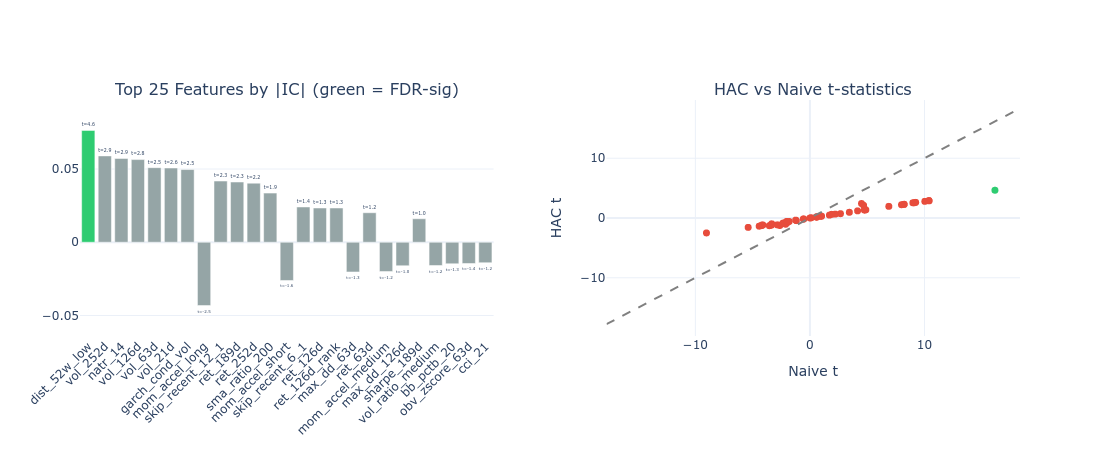

In [15]:
top_n = min(25, len(eval_summary))
top = eval_summary.head(top_n)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"Top {top_n} Features by |IC| (green = FDR-sig)",
        "HAC vs Naive t-statistics",
    ],
    horizontal_spacing=0.12,
)

# Panel 1: IC bar chart
colors = ["#2ecc71" if s else "#95a5a6" for s in top["fdr_sig"].to_list()]
fig.add_trace(
    go.Bar(
        x=top["feature"].to_list(),
        y=top["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"t={t:.1f}" for t in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

# Panel 2: HAC scatter
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=["#2ecc71" if s else "#e74c3c" for s in eval_summary["fdr_sig"].to_list()],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    ),
    row=1,
    col=2,
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color="gray"),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(template="plotly_white", height=450, width=1100)
fig.update_xaxes(tickangle=-45, row=1, col=1)
fig.update_xaxes(title_text="Naive t", row=1, col=2)
fig.update_yaxes(title_text="HAC t", row=1, col=2)
fig.show()

**Interpretation**: Points below the diagonal in the right panel show where
HAC adjustment deflates naive t-statistics. With overlapping 21-day returns,
daily IC values are autocorrelated and naive standard errors understate
uncertainty. The green markers survive both HAC and FDR correction — these
features have genuine standalone predictive power.

## 4. Shape Diagnostics

Quantile monotonicity analysis: does the label spread monotonically across
feature quintiles? A monotone relationship (Q1 < Q2 < ... < Q5 or reverse)
suggests a robust, exploitable signal. Non-monotone shapes may indicate
non-linear interactions or noise.

In [16]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]
if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    valid = eval_panel.select([feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue

    valid = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=[f"Q{i + 1}" for i in range(N_QUANTILES)])
        .alias("quantile")
    )
    q_means = valid.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Shape analysis for {len(quantile_spreads)} features")

Shape analysis for 1 features


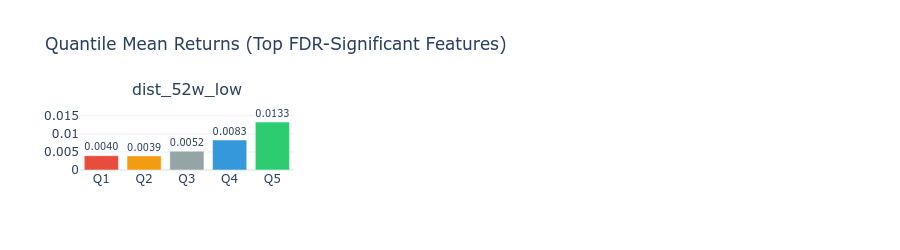

In [17]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show)
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        q_means = quantile_spreads[feat]["q_means"]
        mono = monotonicity_scores.get(feat, 0)
        fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=[
                    "#e74c3c",
                    "#f39c12",
                    "#95a5a6",
                    "#3498db",
                    "#2ecc71",
                ],
                showlegend=False,
                text=[f"{m:.4f}" for m in q_means],
                textposition="outside",
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        template="plotly_white",
        height=250 * n_rows_fig,
        width=900,
        title_text="Quantile Mean Returns (Top FDR-Significant Features)",
    )
    fig.show()

**Interpretation**: Monotone quintile spreads (Q1 → Q5 increasing or
decreasing) confirm a robust relationship. Non-monotone patterns (e.g.,
U-shaped) suggest non-linear effects that may require interaction terms or
tree-based models to capture.

## 5. Redundancy & Feature Families

We group features into interpretive families and compute family-level IC
aggregates. Highly correlated feature pairs (|corr| > 0.7) flag redundancy
that downstream modeling should address via clustering or selection.

In [18]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family based on prefix."""
    FAMILY_MAP = [
        (["sharpe_", "risk_adj"], "risk_adj_momentum"),
        (["skip_recent", "mom_"], "momentum"),
        (["ret_"], "momentum"),
        (["vol_ratio"], "vol_ratio"),
        (["vol_"], "volatility"),
        (["natr", "range_", "max_dd"], "volatility"),
        (["rsi", "macd", "adx", "cci", "stoch", "aroon", "bb_"], "technical"),
        (["sma_", "ema_"], "trend"),
        (["yield_curve", "spy_tlt", "regime", "chop", "hurst"], "regime"),
        (["rank_"], "cross_sectional"),
        (["obv", "turnover", "volume"], "volume"),
        (["pct_positive", "up_ratio"], "consistency"),
        (["dist_"], "distance"),
        (["corr_"], "correlation"),
    ]
    for prefixes, family in FAMILY_MAP:
        if any(p in feature_name.lower() for p in prefixes):
            return family
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

# Override temporal features with specific families
for feat in temporal_cols:
    if "regime" in feat.lower():
        families[feat] = "temporal_regime"
    elif "ffd" in feat.lower():
        families[feat] = "temporal_ffd"
    else:
        families[feat] = "temporal_other"

In [19]:
# Pairwise correlation on sampled dates
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], float(corr_matrix.iloc[i, j])))

print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")

Feature pairs with |corr| > 0.7: 157


In [20]:
# Family-level IC summary
family_ic = {}
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_set,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
else:
    fam_df = pl.DataFrame(
        schema={
            "family": pl.Utf8,
            "n_features": pl.Int64,
            "avg_abs_ic": pl.Float64,
            "avg_ic": pl.Float64,
            "n_fdr_sig": pl.Int64,
        }
    )
print(fam_df)

shape: (10, 5)
┌───────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family            ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---               ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str               ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞═══════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ temporal_other    ┆ 1          ┆ 0.049626   ┆ 0.049626  ┆ 0         │
│ volatility        ┆ 7          ┆ 0.044365   ┆ 0.033978  ┆ 0         │
│ distance          ┆ 2          ┆ 0.041219   ┆ 0.035135  ┆ 1         │
│ momentum          ┆ 14         ┆ 0.023319   ┆ 0.007958  ┆ 0         │
│ volume            ┆ 1          ┆ 0.014516   ┆ -0.014516 ┆ 0         │
│ trend             ┆ 3          ┆ 0.012244   ┆ 0.012244  ┆ 0         │
│ vol_ratio         ┆ 4          ┆ 0.010735   ┆ 0.002789  ┆ 0         │
│ technical         ┆ 8          ┆ 0.009498   ┆ -0.008539 ┆ 0         │
│ risk_adj_momentum ┆ 9          ┆ 0.008073   ┆ 0

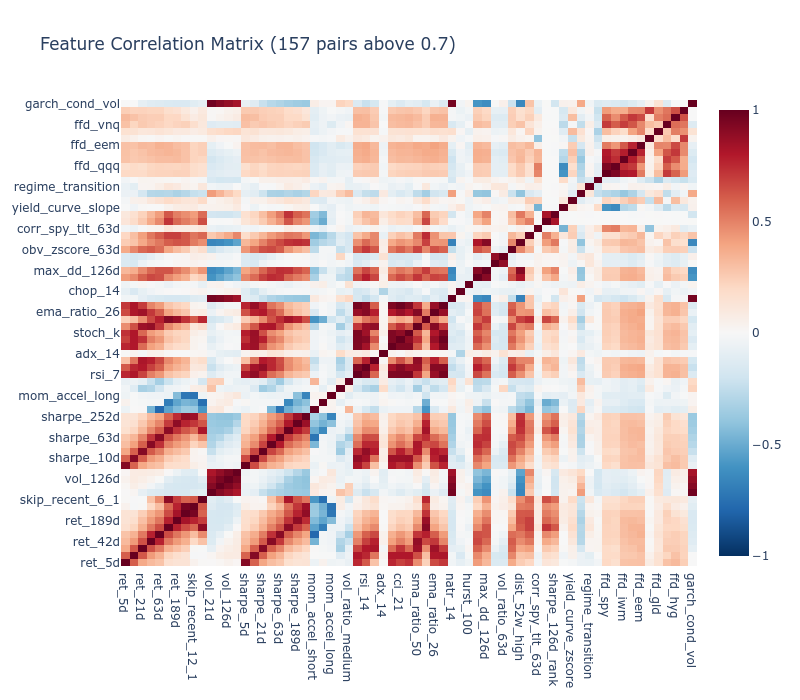

In [21]:
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns.tolist(),
        y=corr_matrix.columns.tolist(),
        colorscale="RdBu_r",
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title=f"Feature Correlation Matrix ({len(high_corr_pairs)} pairs above 0.7)",
    template="plotly_white",
    height=700,
    width=800,
)
fig.show()

**Interpretation**: The correlation heatmap reveals clusters of highly
correlated features — particularly within the momentum (multi-horizon
returns) and volatility (multi-horizon realized vol) families. Downstream
modeling in Ch11 should use clustering or PCA within families to reduce
redundancy, or rely on tree-based models that handle correlated inputs
natively.

## 6. Triage & Handoff

Each feature receives a triage decision:

| Decision | Criteria |
|----------|----------|
| **PROCEED** | FDR-significant at 5%, OR sign consistent across > 60% of folds AND abs(IC) > 0.01 |
| **STOP** | Correctness failure (coverage < 70% or staleness > 50%) |
| **REVISE** | Everything else — evaluate in multivariate context in Ch11 |

Date-level features are triaged as REVISE with a note, since their value
lies in regime-conditional interactions rather than standalone cross-sectional IC.

In [22]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= 0.60 and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [23]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger saved: {EVAL_DIR / 'triage_ledger.parquet'}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger saved: case_studies/etfs/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 17  │
│ REVISE   ┆ 50  │
│ STOP     ┆ 4   │
└──────────┴─────┘


In [24]:
# Save IC time series (long format)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series saved: {EVAL_DIR / 'ic_timeseries.parquet'}")

IC time series saved: case_studies/etfs/evaluation/ic_timeseries.parquet


In [25]:
# Write results JSON
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

sorted_by_ic = sorted(ic_results.items(), key=lambda x: x[1].get("mean_ic") or 0, reverse=True)
best = sorted_by_ic[0] if sorted_by_ic else ("n/a", {})
worst = sorted_by_ic[-1] if sorted_by_ic else ("n/a", {})

In [26]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in proceed_features:
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")


TRIAGE SUMMARY: etfs
  PROCEED: 17 features
  REVISE:  50 features
  STOP:    4 features

PROMOTED (PROCEED) features:
  dist_52w_low                              IC=+0.0764  t=4.64  [distance]
  garch_cond_vol                            IC=+0.0496  t=2.54  [temporal_other]
  natr_14                                   IC=+0.0572  t=2.92  [volatility]
  ret_126d                                  IC=+0.0234  t=1.35  [momentum]
  ret_126d_rank                             IC=+0.0234  t=1.35  [momentum]
  ret_189d                                  IC=+0.0411  t=2.29  [momentum]
  ret_252d                                  IC=+0.0403  t=2.22  [momentum]
  ret_63d                                   IC=+0.0201  t=1.19  [momentum]
  sharpe_189d                               IC=+0.0160  t=0.96  [risk_adj_momentum]
  skip_recent_12_1                          IC=+0.0418  t=2.29  [momentum]
  skip_recent_6_1                           IC=+0.0241  t=1.37  [momentum]
  sma_ratio_200                       

### Quality Gate Verdict

**Fit for modeling.** The triage promotes a broad set of features to PROCEED,
concentrated in the momentum and risk-adjusted momentum families. IC magnitudes
are moderate (0.03--0.04 range), consistent with monthly-horizon cross-sectional
equity signals over a 100-ETF universe. Date-level regime and macro features
are excluded from cross-sectional IC but carry forward as conditioning variables
for tree-based and interaction models in Ch11+.

## Key Takeaways

1. **FDR correction is essential**: With 50+ features, naive p-values
   dramatically overstate the number of true signals. The inflation factor
   quantifies the gap between naive and corrected significance.

2. **HAC adjustment matters**: Overlapping 21-day returns create
   autocorrelation in the IC time series. Newey-West standard errors
   with bandwidth = 21 properly account for this.

3. **Date-level features require special handling**: Regime and macro
   features have zero cross-sectional IC by construction. Their value
   emerges through conditional interactions in Ch11 modeling.

4. **Redundancy within families**: Momentum and volatility features are
   highly correlated. Downstream modeling should cluster or select
   representative features from each family.

**Next**: `05_linear.py` (Ch11) uses the triage ledger and promoted
features for ridge/lasso baseline modeling.